# Regression Comparison
Compare how different models predict future stock returns using CRSP monthly data and Fama-French factors.

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(".."))

# ── Core ──────────────────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
from datetime import date

# ── Plotting ──────────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

# ── Regression / stats ────────────────────────────────────────────────────────
import statsmodels.api as sm
from statsmodels.regression.rolling import RollingOLS
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ── ML models ─────────────────────────────────────────────────────────────────
from sklearn.linear_model import (
    Ridge, Lasso, ElasticNet, LinearRegression, HuberRegressor
)
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

# ── Project modules ───────────────────────────────────────────────────────────
from src.config import (
    ALL_FACTORS, FACTORS_PREBUILT, FACTOR_DISPLAY_NAMES,
    ROLLING_WINDOW, MIN_OBS,
    RAW_DATA_DIR, PROCESSED_DATA_DIR,
)
from src.data_loader import connect_wrds, query, load_cached, fetch_crsp_daily, fetch_ff_factors_daily

# ── Display settings ──────────────────────────────────────────────────────────
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.4f}".format)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

## Load Data
Load from local parquet cache (fast). If cache is missing, fall back to a live WRDS pull.

In [2]:
# ── Date window & split boundaries ───────────────────────────────────────────
PULL_START  = "2010-01-01"
PULL_END    = "2019-12-31"

TRAIN_START = "2010-01-01";  TRAIN_END = "2015-12-31"
BREAK_START = "2016-01-01";  BREAK_END = "2016-12-31"
TEST_START  = "2017-01-01";  TEST_END  = "2019-12-31"

# ── Load from cache; pull from WRDS if missing ───────────────────────────────
crsp_d = load_cached("crsp_daily_2010_2019", RAW_DATA_DIR)
ff_d   = load_cached("ff_daily_2010_2019",   RAW_DATA_DIR)

if crsp_d is None or ff_d is None:
    print("Cache miss — connecting to WRDS (this may take a few minutes)...")
    from src.data_loader import save_cache
    conn   = connect_wrds()
    crsp_d = fetch_crsp_daily(conn, PULL_START, PULL_END)
    ff_d   = fetch_ff_factors_daily(conn, PULL_START, PULL_END)
    conn.close()
    save_cache(crsp_d, "crsp_daily_2010_2019", RAW_DATA_DIR)
    save_cache(ff_d,   "ff_daily_2010_2019",   RAW_DATA_DIR)
    print("Saved to cache.")

print(f"CRSP daily:  {crsp_d.shape:}  | {crsp_d['date'].min().date()} → {crsp_d['date'].max().date()}")
print(f"FF daily:    {ff_d.shape:}    | {ff_d['date'].min().date()} → {ff_d['date'].max().date()}")
crsp_d.head(3)

CRSP daily:  (9355531, 13)  | 2010-01-04 → 2019-12-31
FF daily:    (2516, 8)    | 2010-01-04 → 2019-12-31


,permno,date,ret,retx,prc,shrout,vol,exchcd,shrcd,ticker,comnam,siccd,mcap
0,10001,2010-01-04,-0.0049,-0.0049,10.2500,4361.0000,18500.0000,2,11,EGAS,ENERGY INC,4925,44700.2500
1,10002,2010-01-04,0.0801,0.0801,3.1000,17634.0000,27845.0000,3,11,BTFG,BANCTRUST FINANCIAL GROUP INC,6020,54665.4000
2,10025,2010-01-04,0.0334,0.0334,39.5600,6852.0000,33721.0000,3,11,AEPI,A E P INDUSTRIES INC,3081,271065.1200


## Build Panel & Split

In [3]:
FACTORS = FACTORS_PREBUILT  # ["mktrf", "smb", "hml", "rmw", "cma", "umd"]

panel = crsp_d.merge(ff_d[["date", "rf"] + FACTORS], on="date", how="inner")
panel["excess_ret"] = panel["ret"] - panel["rf"]
panel = panel.dropna(subset=["excess_ret"] + FACTORS).sort_values(["permno", "date"]).reset_index(drop=True)

def split(df, start, end):
    return df[(df["date"] >= start) & (df["date"] <= end)].copy()

train = split(panel, TRAIN_START, TRAIN_END)
brk   = split(panel, BREAK_START, BREAK_END)
test  = split(panel, TEST_START,  TEST_END)

for name, df in [("train", train), ("break", brk), ("test", test)]:
    print(f"{name:6s}  {df['date'].min().date()} → {df['date'].max().date()}"
          f"  |  {df['permno'].nunique():,} stocks  |  {len(df):,} obs")

train   2010-01-04 → 2015-12-31  |  5,331 stocks  |  5,722,632 obs
break   2016-01-04 → 2016-12-30  |  3,902 stocks  |  923,207 obs
test    2017-01-03 → 2019-12-31  |  4,283 stocks  |  2,709,692 obs


## 28-Day Forward Return
For each row, compute the compounded return over the next 28 trading days (~1 calendar month).

**Method:** cumulative log-return trick per stock — `fwd[t] = exp(cumlog[t+28] − cumlog[t]) − 1`.  
This is exact compounding with no loops. Rows in the final 28 trading days of each stock's history become NaN and are dropped at model time.

In [4]:
N_FWD = 28  # trading days ≈ 1 calendar month

def _fwd_compounded(s, n):
    """Compound forward n-period return via log-return cumsum trick.
    fwd[t] = exp( cumlog[t+n] - cumlog[t] ) - 1
    """
    cum = np.log1p(s).cumsum()
    return np.expm1(cum.shift(-n) - cum)

# Raw forward return
panel["fwd_ret_28d"] = (
    panel.groupby("permno", group_keys=False)["ret"]
    .transform(lambda s: _fwd_compounded(s, N_FWD))
)

# Excess forward return (compound excess_ret the same way)
panel["fwd_excess_ret_28d"] = (
    panel.groupby("permno", group_keys=False)["excess_ret"]
    .transform(lambda s: _fwd_compounded(s, N_FWD))
)

n_total = len(panel)
n_valid = panel["fwd_ret_28d"].notna().sum()
print(f"Total rows:          {n_total:,}")
print(f"Rows with target:    {n_valid:,}  ({100 * n_valid / n_total:.1f}%)")
print(f"Rows NaN (tail):     {n_total - n_valid:,}")
panel[["permno", "date", "ret", "excess_ret", "fwd_ret_28d", "fwd_excess_ret_28d"]].head(10)

Total rows:          9,355,531
Rows with target:    9,184,046  (98.2%)
Rows NaN (tail):     171,485


,permno,date,ret,excess_ret,fwd_ret_28d,fwd_excess_ret_28d
0,10001,2010-01-04,-0.0049,-0.0049,-0.0084,-0.0084
1,10001,2010-01-05,-0.0059,-0.0059,-0.0008,-0.0008
2,10001,2010-01-06,0.0118,0.0118,-0.0215,-0.0215
3,10001,2010-01-07,-0.0339,-0.0339,0.0200,0.0200
4,10001,2010-01-08,0.0382,0.0382,-0.0233,-0.0233
5,10001,2010-01-11,0.0155,0.0155,-0.0449,-0.0449
6,10001,2010-01-12,-0.0048,-0.0048,-0.0423,-0.0423
7,10001,2010-01-13,-0.0033,-0.0033,-0.0217,-0.0217
8,10001,2010-01-14,-0.0019,-0.0019,-0.0256,-0.0256
9,10001,2010-01-15,-0.0077,-0.0077,-0.0211,-0.0211


## Feature Engineering
All features are constructed with strict look-ahead safety (only data available at time *t* is used).

In [5]:
panel = panel.sort_values(["permno", "date"]).reset_index(drop=True)
g = panel.groupby("permno", group_keys=False)

# ── 1. Short-term reversal ────────────────────────────────────────────────────
panel["ret_lag1"] = g["ret"].transform(lambda s: s.shift(1))

# ── 2. Momentum (compounded past returns, skip most-recent day) ──────────────
def _past_ret(s, n):
    return np.expm1(np.log1p(s).shift(1).rolling(n, min_periods=n // 2).sum())

for n, label in [(5, "5d"), (21, "21d"), (63, "63d"), (126, "126d"), (252, "252d")]:
    panel[f"mom_{label}"] = g["ret"].transform(_past_ret, n=n)

# ── 3. 52-week high ratio ─────────────────────────────────────────────────────
panel["high_52w_ratio"] = g["prc"].transform(
    lambda s: s.abs() / s.abs().rolling(252, min_periods=126).max()
)

# ── 4. Realized volatility ────────────────────────────────────────────────────
for n, label in [(21, "21d"), (63, "63d")]:
    panel[f"rvol_{label}"] = g["ret"].transform(
        lambda s, n=n: s.rolling(n, min_periods=n // 2).std()
    )

# ── 5. Downside volatility ────────────────────────────────────────────────────
panel["dvol_21d"] = g["ret"].transform(
    lambda s: s.clip(upper=0).rolling(21, min_periods=10).std()
)

# ── 6. Amihud illiquidity ─────────────────────────────────────────────────────
_dollar_vol   = panel["prc"].abs() * panel["vol"]
_amihud_daily = panel["ret"].abs() / _dollar_vol.replace(0, np.nan)
panel["amihud_21d"] = (
    _amihud_daily.groupby(panel["permno"]).transform(
        lambda s: s.rolling(21, min_periods=10).mean()
    )
)

# ── 7. Turnover ───────────────────────────────────────────────────────────────
_turnover_daily = panel["vol"] / panel["shrout"].replace(0, np.nan)
panel["turnover_21d"] = (
    _turnover_daily.groupby(panel["permno"]).transform(
        lambda s: s.rolling(21, min_periods=10).mean()
    )
)

# ── 8. Log market cap & log price ─────────────────────────────────────────────
panel["log_mcap"] = np.log(panel["mcap"].replace(0, np.nan))
panel["log_prc"]  = np.log(panel["prc"].abs().replace(0, np.nan))

# ── 9. Price-to-moving-average ratios ─────────────────────────────────────────
_prc_abs = panel["prc"].abs()
panel["prc_to_ma50"]  = _prc_abs / g["prc"].transform(
    lambda s: s.abs().rolling(50,  min_periods=25).mean()
)
panel["prc_to_ma200"] = _prc_abs / g["prc"].transform(
    lambda s: s.abs().rolling(200, min_periods=100).mean()
)

# ── 10. Rolling market beta ───────────────────────────────────────────────────
# Trailing 252-day OLS slope: beta_i = cov(ret_i, mktrf) / var(mktrf)
# Fully vectorized via the identity: cov(r, m) = E[r·m] - E[r]·E[m]
#                                    var(m)    = E[m²]  - E[m]²
panel["_rm"]  = panel["excess_ret"] * panel["mktrf"]

_roll_rm = g["_rm"].transform(lambda s: s.rolling(252, min_periods=60).mean())
_roll_r  = g["excess_ret"].transform(lambda s: s.rolling(252, min_periods=60).mean())
_roll_m  = g["mktrf"].transform(lambda s: s.rolling(252, min_periods=60).mean())
_roll_m2 = g["mktrf"].transform(lambda s: (s ** 2).rolling(252, min_periods=60).mean())

panel["beta_mkt"] = (_roll_rm - _roll_r * _roll_m) / (_roll_m2 - _roll_m ** 2)
panel.drop(columns=["_rm"], inplace=True)

# ── Summary ───────────────────────────────────────────────────────────────────
new_features = (
    ["beta_mkt"]
    + ["ret_lag1"]
    + [f"mom_{l}" for l in ["5d", "21d", "63d", "126d", "252d"]]
    + ["high_52w_ratio"]
    + ["rvol_21d", "rvol_63d", "dvol_21d"]
    + ["amihud_21d", "turnover_21d"]
    + ["log_mcap", "log_prc"]
    + ["prc_to_ma50", "prc_to_ma200"]
)

print(f"New features added : {len(new_features)}")
print(f"Panel shape        : {panel.shape}")
print()
print("Non-null rates per feature:")
print(panel[new_features].notna().mean().round(3).to_string())

New features added : 17
Panel shape        : (9355531, 40)

Non-null rates per feature:
beta_mkt         0.9620
ret_lag1         0.9990
mom_5d           0.9990
mom_21d          0.9930
mom_63d          0.9800
mom_126d         0.9590
mom_252d         0.9190
high_52w_ratio   0.9200
rvol_21d         0.9940
rvol_63d         0.9800
dvol_21d         0.9940
amihud_21d       0.9900
turnover_21d     0.9940
log_mcap         1.0000
log_prc          1.0000
prc_to_ma50      0.9840
prc_to_ma200     0.9360


## Monthly Subsampling
Daily 28-day forward returns overlap by 27/28 days — successive rows carry almost identical
target information. This inflates N without adding signal, causes massive residual
autocorrelation, and blows up memory.

**Fix:** keep only the last trading day of each (stock × month). Features and targets were
already computed on the full daily panel, so no information is lost — we're just sampling
non-overlapping prediction windows.

In [6]:
# Keep last trading day per (stock × month)
panel["ym"] = panel["date"].dt.to_period("M")
eom_idx = panel.groupby(["permno", "ym"])["date"].idxmax()
pm = panel.loc[eom_idx].reset_index(drop=True)

# ── Cross-sectional rank target ───────────────────────────────────────────────
# Rank each stock's 28d forward return within its month (percentile 0→1).
# This removes the common market move so the model only needs to predict
# which stocks beat their peers, not the level of the market.
pm["fwd_ret_rank"] = (
    pm.groupby("ym")["fwd_excess_ret_28d"]
    .rank(pct=True)
)

print(f"Daily panel: {len(panel):>10,} rows")
print(f"Monthly sub: {len(pm):>10,} rows  ({len(pm)/len(panel)*100:.1f}%)")
print(f"Stocks:      {pm['permno'].nunique():>10,}")
print(f"Months:      {pm['ym'].nunique():>10}")
print(f"\nRank target — mean: {pm['fwd_ret_rank'].mean():.3f}  std: {pm['fwd_ret_rank'].std():.3f}  range: [{pm['fwd_ret_rank'].min():.3f}, {pm['fwd_ret_rank'].max():.3f}]")

Daily panel:  9,355,531 rows
Monthly sub:    448,387 rows  (4.8%)
Stocks:           6,150
Months:             120

Rank target — mean: 0.500  std: 0.289  range: [0.000, 1.000]


---
## Experiment: Does Market Beta Predict Cross-Sectional Returns?

Six models in a 2×3 design predicting the **cross-sectional rank** of 28-day forward excess return on the monthly subsample:

|  | **OLS** | **Ridge** | **Lasso** |
|--|---------|-----------|-----------|
| **Group A — beta_mkt included** | A1 | A2 | A3 |
| **Group B — residualized against beta_mkt** | B1 | B2 | B3 |

**Target:** `fwd_ret_rank` — each stock's percentile rank (0→1) within its month's cross-section.

**Features (17, all stock-specific):**
All features vary cross-sectionally — date-level factors (`mktrf`, `smb`, `hml`, etc. and their lags/rolling versions) are dropped because they are constant within a month's cross-section and carry no cross-sectional predictive information.

| Group | Features |
|-------|----------|
| Return signals (7) | `ret_lag1`, `mom_5d/21d/63d/126d/252d`, `high_52w_ratio` |
| Volatility (3) | `rvol_21d`, `rvol_63d`, `dvol_21d` |
| Liquidity (2) | `amihud_21d`, `turnover_21d` |
| Price / size (4) | `log_mcap`, `log_prc`, `prc_to_ma50`, `prc_to_ma200` |
| **Market sensitivity (1)** | **`beta_mkt`** — trailing 252-day OLS beta vs market |

**Group A** includes estimated `beta_mkt` directly alongside all other stock-specific features.  
**Group B** removes the `beta_mkt` component from every other feature via OLS projection (`X_resid = X − β̂·beta_mkt`), then drops `beta_mkt` itself.

**What we learn:**
- **A1 vs B1 (OLS):** Frisch-Waugh-Lovell guarantees identical predictions — built-in sanity check.
- **A3 (Lasso):** Does Lasso keep or zero out `beta_mkt`? If kept, beta is a real cross-sectional signal. If dropped, beta is already absorbed by correlated features (size, volatility).
- **A vs B overall:** Does a stock's market sensitivity help predict whether it beats peers?
- **Economic link:** Related to the low-beta anomaly (Frazzini & Pedersen 2014 BAB factor) — low-beta stocks tend to outperform high-beta stocks on a risk-adjusted basis.

In [7]:
TARGET = "fwd_ret_rank"   # cross-sectional percentile rank within each month

# ── Feature set: stock-specific only (17 features) ───────────────────────────
# Date-level features (mktrf, smb, hml, rmw, cma, umd and all their lags/rolling
# versions, plus month) are constant within a month's cross-section — zero
# cross-sectional variance → useless for predicting relative performance → dropped.
FEATURE_COLS = (
    ["beta_mkt"]   # trailing 252-day estimated market sensitivity (stock-specific)
    + ["ret_lag1", "mom_5d", "mom_21d", "mom_63d", "mom_126d", "mom_252d", "high_52w_ratio"]
    + ["rvol_21d", "rvol_63d", "dvol_21d"]
    + ["amihud_21d", "turnover_21d"]
    + ["log_mcap", "log_prc", "prc_to_ma50", "prc_to_ma200"]
)

BASE_FEATURES = [f for f in FEATURE_COLS if f != "beta_mkt"]  # 16 features for Group B

print(f"Total features: {len(FEATURE_COLS)}")
for group, cols in [
    ("Market sensitivity (1)", ["beta_mkt"]),
    ("Return signals (7)",     ["ret_lag1","mom_5d","mom_21d","mom_63d","mom_126d","mom_252d","high_52w_ratio"]),
    ("Volatility (3)",         ["rvol_21d","rvol_63d","dvol_21d"]),
    ("Liquidity (2)",          ["amihud_21d","turnover_21d"]),
    ("Price/size (4)",         ["log_mcap","log_prc","prc_to_ma50","prc_to_ma200"]),
]:
    print(f"  {group}")

# ── Train / break / test on monthly subsample ─────────────────────────────────
train_s = pm[(pm["date"] >= TRAIN_START) & (pm["date"] <= TRAIN_END)].copy()
brk_s   = pm[(pm["date"] >= BREAK_START) & (pm["date"] <= BREAK_END)].copy()
test_s  = pm[(pm["date"] >= TEST_START)  & (pm["date"] <= TEST_END)].copy()

def _clean(df, cols):
    extra = [c for c in [TARGET] if c not in cols]
    return df[cols + extra].dropna()

train_a = _clean(train_s, FEATURE_COLS).copy()
brk_a   = _clean(brk_s,   FEATURE_COLS)
test_a  = _clean(test_s,   FEATURE_COLS)

scaler_a  = StandardScaler().fit(train_a[FEATURE_COLS])
X_train_a = scaler_a.transform(train_a[FEATURE_COLS])
X_brk_a   = scaler_a.transform(brk_a[FEATURE_COLS])
X_test_a  = scaler_a.transform(test_a[FEATURE_COLS])

y_train = train_a[TARGET].values
y_brk   = brk_a[TARGET].values
y_test  = test_a[TARGET].values

# ── Residualize base features against beta_mkt (Group B) ─────────────────────
# Remove the beta_mkt component from every other feature via OLS projection:
#   X_resid_j = X_j - (X_j · beta_mkt / ||beta_mkt||²) · beta_mkt
beta_col   = FEATURE_COLS.index("beta_mkt")
beta_train = X_train_a[:, beta_col]

proj_betas = {
    col: np.dot(X_train_a[:, FEATURE_COLS.index(col)], beta_train) / np.dot(beta_train, beta_train)
    for col in BASE_FEATURES
}

def _residualize(X_full, betas):
    b_vals = X_full[:, beta_col]
    out    = np.empty((X_full.shape[0], len(BASE_FEATURES)))
    for j, col in enumerate(BASE_FEATURES):
        out[:, j] = X_full[:, FEATURE_COLS.index(col)] - betas[col] * b_vals
    return out

X_train_b = _residualize(X_train_a, proj_betas)
X_brk_b   = _residualize(X_brk_a,   proj_betas)
X_test_b  = _residualize(X_test_a,   proj_betas)
FEATURES_B = [f"{c}_resid" for c in BASE_FEATURES]

print(f"\nTrain: {len(y_train):,}  |  Break: {len(y_brk):,}  |  Test: {len(y_test):,}")
print(f"Target mean: {y_train.mean():.3f}  std: {y_train.std():.3f}")

Total features: 17
  Market sensitivity (1)
  Return signals (7)
  Volatility (3)
  Liquidity (2)
  Price/size (4)



Train: 238,567  |  Break: 42,428  |  Test: 117,117
Target mean: 0.501  std: 0.287


In [ ]:
import warnings
from sklearn.linear_model import LinearRegression, Lasso, LassoCV, Ridge

# ── Shared helpers ────────────────────────────────────────────────────────────
def metrics_row(y_true, y_pred):
    if np.std(y_pred) < 1e-12:
        return {"R²": 0.0, "RMSE": float(np.sqrt(mean_squared_error(y_true, y_pred))),
                "IC": float("nan"), "Rank IC": float("nan")}
    return {
        "R²":      r2_score(y_true, y_pred),
        "RMSE":    float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "IC":      float(np.corrcoef(y_pred, y_true)[0, 1]),
        "Rank IC": float(pd.Series(y_pred).corr(pd.Series(y_true), method="spearman")),
    }

def eval_model(X_tr, X_bk, X_te, model):
    model.fit(X_tr, y_train)
    preds = {s: model.predict(X) for s, X in [("train", X_tr), ("break", X_bk), ("test", X_te)]}
    return {s: metrics_row(y, preds[s]) for s, y in [("train", y_train), ("break", y_brk), ("test", y_test)]} | {"model": model, "preds": preds}

tscv       = TimeSeriesSplit(n_splits=5)
date_order = train_s.loc[train_a.index, "date"].values.argsort()

def _sort(X): return X[date_order]

def cv_eval(X_tr, model_fn):
    X_s, y_s = _sort(X_tr), y_train[date_order]
    rows = []
    for tr_idx, val_idx in tscv.split(X_s):
        m = model_fn().fit(X_s[tr_idx], y_s[tr_idx])
        rows.append(metrics_row(y_s[val_idx], m.predict(X_s[val_idx])))
    return pd.DataFrame(rows).mean().to_dict()

def tune_lasso(X_tr, alphas):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        lasso_cv = LassoCV(alphas=alphas, cv=tscv, max_iter=50000)
        lasso_cv.fit(_sort(X_tr), y_train[date_order])
    plot_alphas = lasso_cv.alphas_[::-1]
    plot_mse    = lasso_cv.mse_path_.mean(axis=1)[::-1]
    return lasso_cv.alpha_, plot_alphas, plot_mse

def tune_ridge(X_tr, alphas):
    X_s, y_s = _sort(X_tr), y_train[date_order]
    cv_mse = []
    for alpha in alphas:
        fold_mse = [
            mean_squared_error(y_s[val], Ridge(alpha=alpha).fit(X_s[tr], y_s[tr]).predict(X_s[val]))
            for tr, val in tscv.split(X_s)
        ]
        cv_mse.append(np.mean(fold_mse))
    cv_mse = np.array(cv_mse)
    return alphas[np.argmin(cv_mse)], cv_mse

lasso_alphas = np.logspace(-6, 1, 100)
ridge_alphas = np.logspace(-3, 10, 100)

# ── Group A: beta_mkt included ────────────────────────────────────────────────
print("Fitting Group A (beta_mkt included)...")
best_lasso_a, lasso_plot_alphas_a, lasso_plot_mse_a = tune_lasso(X_train_a, lasso_alphas)
best_ridge_a, ridge_cv_mse_a                        = tune_ridge(X_train_a, ridge_alphas)
print(f"  Lasso α={best_lasso_a:.2e}  |  Ridge α={best_ridge_a:.2e}")

res, cv = {}, {}
res["A1: OLS"]   = eval_model(X_train_a, X_brk_a, X_test_a, LinearRegression())
res["A2: Ridge"] = eval_model(X_train_a, X_brk_a, X_test_a, Ridge(alpha=best_ridge_a))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res["A3: Lasso"] = eval_model(X_train_a, X_brk_a, X_test_a, Lasso(alpha=best_lasso_a, max_iter=50000))

cv["A1: OLS"]   = cv_eval(X_train_a, LinearRegression)
cv["A2: Ridge"] = cv_eval(X_train_a, lambda: Ridge(alpha=best_ridge_a))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cv["A3: Lasso"] = cv_eval(X_train_a, lambda: Lasso(alpha=best_lasso_a, max_iter=50000))

# ── Group B: residualized against beta_mkt ───────────────────────────────────
print("Fitting Group B (residualized against beta_mkt)...")
best_lasso_b, lasso_plot_alphas_b, lasso_plot_mse_b = tune_lasso(X_train_b, lasso_alphas)
best_ridge_b, ridge_cv_mse_b                        = tune_ridge(X_train_b, ridge_alphas)
print(f"  Lasso α={best_lasso_b:.2e}  |  Ridge α={best_ridge_b:.2e}")

res["B1: OLS"]   = eval_model(X_train_b, X_brk_b, X_test_b, LinearRegression())
res["B2: Ridge"] = eval_model(X_train_b, X_brk_b, X_test_b, Ridge(alpha=best_ridge_b))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res["B3: Lasso"] = eval_model(X_train_b, X_brk_b, X_test_b, Lasso(alpha=best_lasso_b, max_iter=50000))

cv["B1: OLS"]   = cv_eval(X_train_b, LinearRegression)
cv["B2: Ridge"] = cv_eval(X_train_b, lambda: Ridge(alpha=best_ridge_b))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cv["B3: Lasso"] = cv_eval(X_train_b, lambda: Lasso(alpha=best_lasso_b, max_iter=50000))

# ── Group C: beta_mkt dropped entirely ───────────────────────────────────────
# Directly answers: is beta_mkt helpful, harmful, or neutral as a raw feature?
# C vs A: effect of including beta_mkt
# C vs B: effect of residualization vs simple omission
print("Fitting Group C (beta_mkt dropped entirely)...")

X_train_c = X_train_a[:, [i for i, f in enumerate(FEATURE_COLS) if f != "beta_mkt"]]
X_brk_c   = X_brk_a[:,   [i for i, f in enumerate(FEATURE_COLS) if f != "beta_mkt"]]
X_test_c  = X_test_a[:,   [i for i, f in enumerate(FEATURE_COLS) if f != "beta_mkt"]]

best_lasso_c, lasso_plot_alphas_c, lasso_plot_mse_c = tune_lasso(X_train_c, lasso_alphas)
best_ridge_c, ridge_cv_mse_c                        = tune_ridge(X_train_c, ridge_alphas)
print(f"  Lasso α={best_lasso_c:.2e}  |  Ridge α={best_ridge_c:.2e}")

res["C1: OLS"]   = eval_model(X_train_c, X_brk_c, X_test_c, LinearRegression())
res["C2: Ridge"] = eval_model(X_train_c, X_brk_c, X_test_c, Ridge(alpha=best_ridge_c))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    res["C3: Lasso"] = eval_model(X_train_c, X_brk_c, X_test_c, Lasso(alpha=best_lasso_c, max_iter=50000))

cv["C1: OLS"]   = cv_eval(X_train_c, LinearRegression)
cv["C2: Ridge"] = cv_eval(X_train_c, lambda: Ridge(alpha=best_ridge_c))
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    cv["C3: Lasso"] = cv_eval(X_train_c, lambda: Lasso(alpha=best_lasso_c, max_iter=50000))

# ── Comparison table ──────────────────────────────────────────────────────────
for split_name in ["CV mean", "train", "test"]:
    rows = {k: cv[k] if split_name == "CV mean" else res[k][split_name] for k in res}
    print(f"\n{'─'*65}\n  {split_name.upper()}\n{'─'*65}")
    print(pd.DataFrame(rows).T[["R²", "Rank IC"]].to_string())

# ── Lasso feature selection summary ──────────────────────────────────────────
for label, coefs, feat_names in [
    ("A3: Lasso", res["A3: Lasso"]["model"].coef_, FEATURE_COLS),
    ("B3: Lasso", res["B3: Lasso"]["model"].coef_, FEATURES_B),
    ("C3: Lasso", res["C3: Lasso"]["model"].coef_, BASE_FEATURES),
]:
    s     = pd.Series(coefs, index=feat_names)
    alive = s[s != 0]
    print(f"\n{label}  |  {len(alive)} kept / {len(s)-len(alive)} dropped")
    if "beta_mkt" in feat_names:
        print(f"  beta_mkt: {s['beta_mkt']:.6f}  →  {'KEPT' if s['beta_mkt'] != 0 else 'DROPPED'}")
    print(f"  Kept: {alive.sort_values().index.tolist()}")

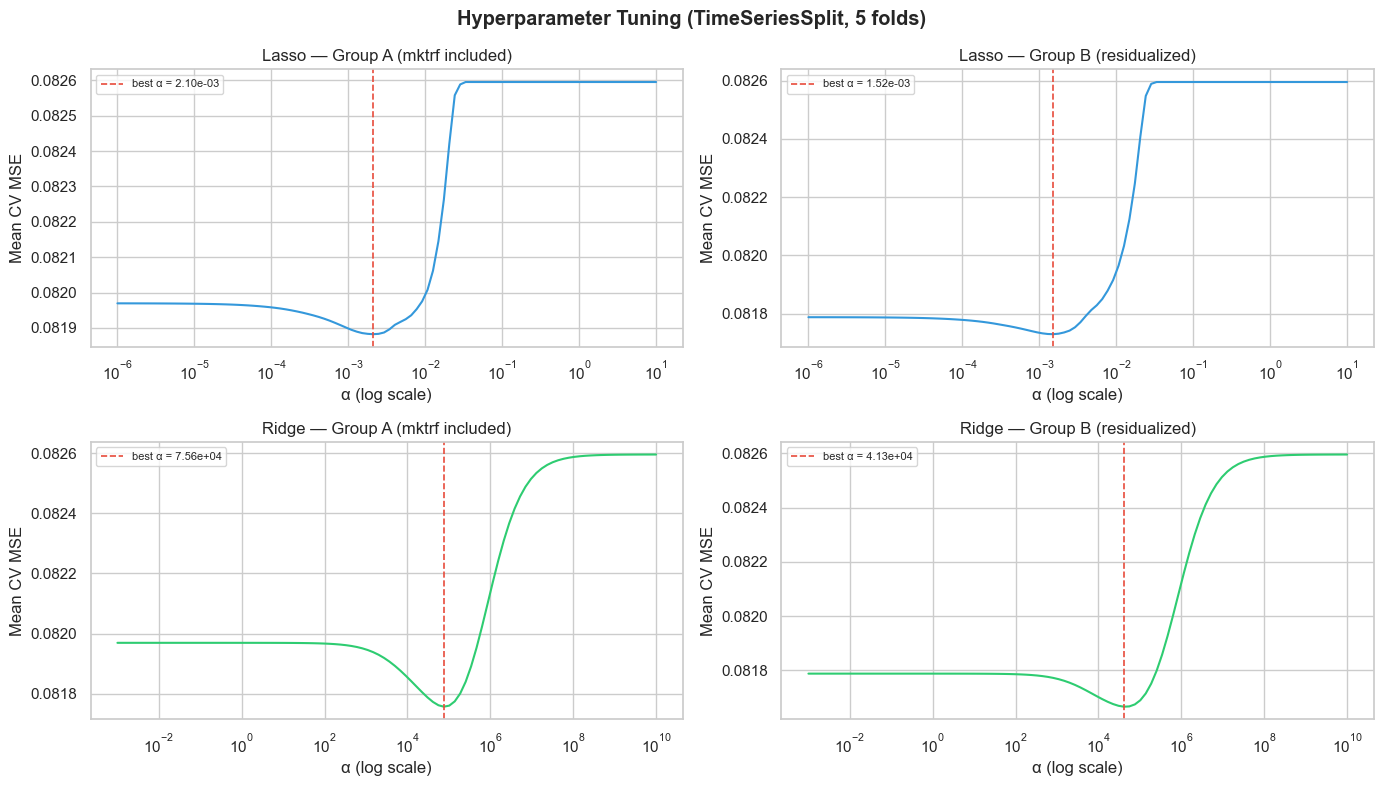

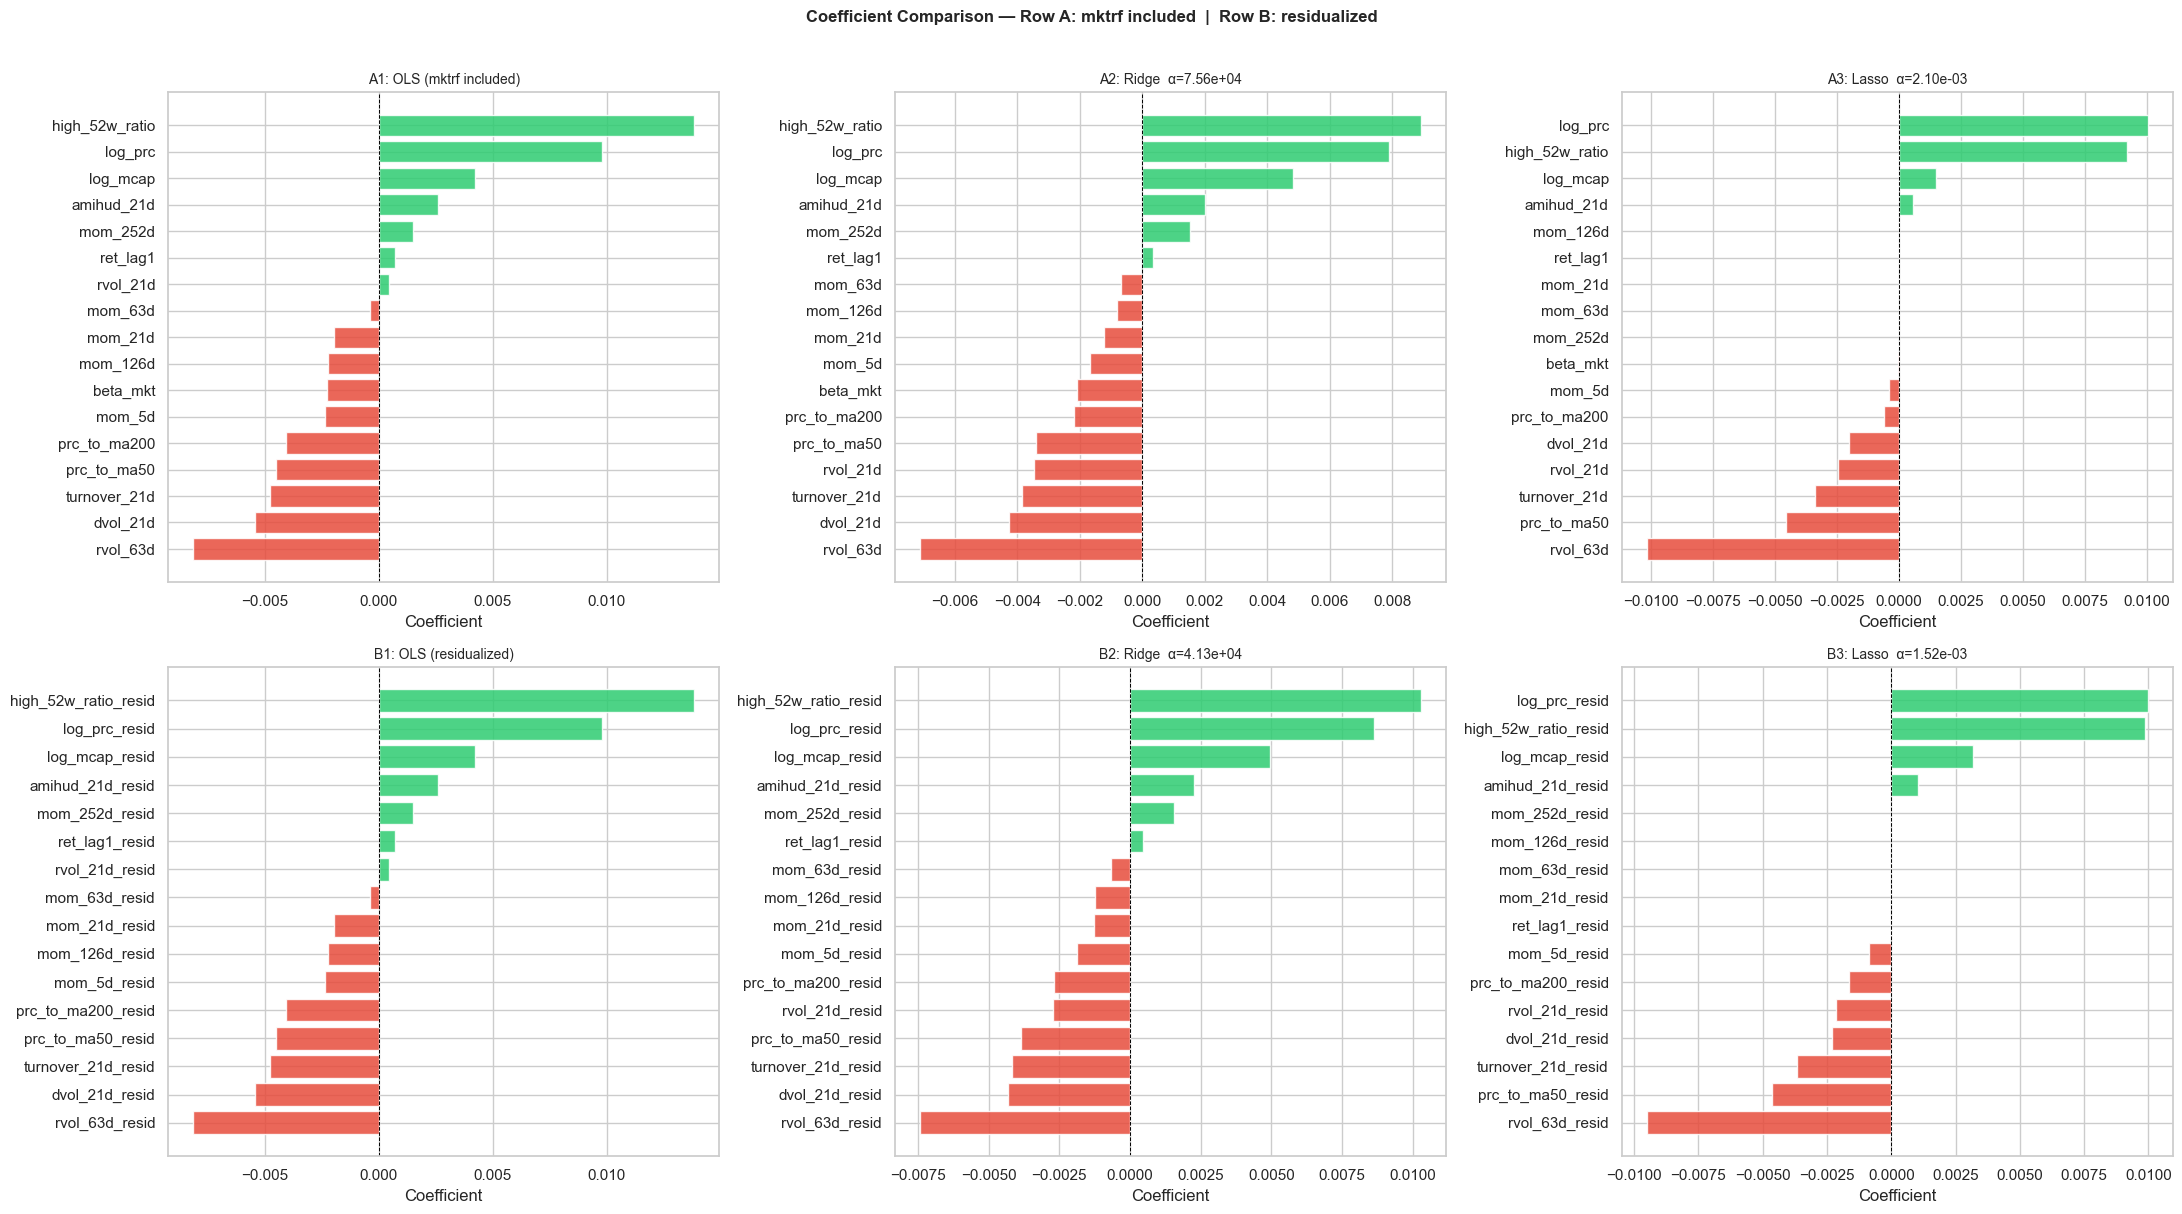


A3: Lasso  |  12 kept / 5 dropped
  Kept: ['rvol_63d', 'prc_to_ma50', 'turnover_21d', 'rvol_21d', 'dvol_21d', 'prc_to_ma200', 'mom_5d', 'beta_mkt', 'amihud_21d', 'log_mcap', 'high_52w_ratio', 'log_prc']

B3: Lasso  |  11 kept / 5 dropped
  Kept: ['rvol_63d_resid', 'prc_to_ma50_resid', 'turnover_21d_resid', 'dvol_21d_resid', 'rvol_21d_resid', 'prc_to_ma200_resid', 'mom_5d_resid', 'amihud_21d_resid', 'log_mcap_resid', 'high_52w_ratio_resid', 'log_prc_resid']


In [9]:
# ── Plot 1: Hyperparameter tuning curves (2×2) ───────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

def _tune_plot(ax, alphas, mse, best_alpha, title, color):
    ax.semilogx(alphas, mse, color=color, linewidth=1.5)
    ax.axvline(best_alpha, color="#e74c3c", linestyle="--", linewidth=1.2,
               label=f"best α = {best_alpha:.2e}")
    ax.set_title(title)
    ax.set_xlabel("α (log scale)")
    ax.set_ylabel("Mean CV MSE")
    ax.legend(fontsize=8)

_tune_plot(axes[0,0], lasso_plot_alphas_a, lasso_plot_mse_a, best_lasso_a,
           "Lasso — Group A (mktrf included)", "#3498db")
_tune_plot(axes[0,1], lasso_plot_alphas_b, lasso_plot_mse_b, best_lasso_b,
           "Lasso — Group B (residualized)",  "#3498db")
_tune_plot(axes[1,0], ridge_alphas, ridge_cv_mse_a, best_ridge_a,
           "Ridge — Group A (mktrf included)", "#2ecc71")
_tune_plot(axes[1,1], ridge_alphas, ridge_cv_mse_b, best_ridge_b,
           "Ridge — Group B (residualized)",  "#2ecc71")

plt.suptitle("Hyperparameter Tuning (TimeSeriesSplit, 5 folds)", fontweight="bold")
plt.tight_layout()
plt.show()

# ── Plot 2: Coefficients — 2 rows × 3 cols ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(22, 12))

def _coef_bar(ax, coefs, labels, title):
    s = pd.Series(coefs, index=labels).sort_values()
    colors = ["#e74c3c" if v < 0 else "#2ecc71" for v in s]
    ax.barh(s.index, s.values, color=colors, alpha=0.85)
    ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
    ax.set_title(title, fontsize=10)
    ax.set_xlabel("Coefficient")

_coef_bar(axes[0,0], res["A1: OLS"]["model"].coef_,   FEATURE_COLS, "A1: OLS (mktrf included)")
_coef_bar(axes[0,1], res["A2: Ridge"]["model"].coef_, FEATURE_COLS, f"A2: Ridge  α={best_ridge_a:.2e}")
_coef_bar(axes[0,2], res["A3: Lasso"]["model"].coef_, FEATURE_COLS, f"A3: Lasso  α={best_lasso_a:.2e}")
_coef_bar(axes[1,0], res["B1: OLS"]["model"].coef_,   FEATURES_B,   "B1: OLS (residualized)")
_coef_bar(axes[1,1], res["B2: Ridge"]["model"].coef_, FEATURES_B,   f"B2: Ridge  α={best_ridge_b:.2e}")
_coef_bar(axes[1,2], res["B3: Lasso"]["model"].coef_, FEATURES_B,   f"B3: Lasso  α={best_lasso_b:.2e}")

plt.suptitle("Coefficient Comparison — Row A: mktrf included  |  Row B: residualized",
             fontsize=12, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Lasso selection summary ───────────────────────────────────────────────────
for label, coefs, feat_names in [
    ("A3: Lasso", res["A3: Lasso"]["model"].coef_, FEATURE_COLS),
    ("B3: Lasso", res["B3: Lasso"]["model"].coef_, FEATURES_B),
]:
    s     = pd.Series(coefs, index=feat_names)
    alive = s[s != 0]
    dead  = s[s == 0].index.tolist()
    print(f"\n{label}  |  {len(alive)} kept / {len(dead)} dropped")
    if "mktrf" in feat_names:
        print(f"  mktrf: {s['mktrf']:.6f}  →  {'KEPT' if s['mktrf'] != 0 else 'DROPPED'}")
    if len(alive):
        print(f"  Kept: {alive.sort_values().index.tolist()}")

---
## Fama-MacBeth Regression

Run a separate cross-sectional OLS each month, then average coefficients over time.

**Why FM instead of pooled OLS:**
- Coefficients are purely cross-sectional — identified from which stocks beat peers each month, not from time-series variation
- Standard errors from the time-series of monthly betas automatically account for cross-sectional correlation (all stocks share the same market shock in a given month)
- Natural alignment with the rank target, which is already defined within each month's cross-section

**Feature restriction:** Date-level features (`mktrf`, `smb`, `hml`, and all lagged/rolling FF factors, `month`) are constant across stocks within any single month — collinear with the intercept. FM uses the 16 stock-specific features only.

FM features (17): ['beta_mkt', 'ret_lag1', 'mom_5d', 'mom_21d', 'mom_63d', 'mom_126d', 'mom_252d', 'high_52w_ratio', 'rvol_21d', 'rvol_63d', 'dvol_21d', 'amihud_21d', 'turnover_21d', 'log_mcap', 'log_prc', 'prc_to_ma50', 'prc_to_ma200']

Months with valid regression: 66 / 72

Fama-MacBeth estimates (train 2010–2015):
                    β̄     SE  t-stat  sig
rvol_63d       -0.0120 0.0021 -5.7231  ***
amihud_21d      0.0035 0.0008  4.2616  ***
high_52w_ratio  0.0119 0.0037  3.2344  ***
dvol_21d       -0.0064 0.0021 -3.0211  ***
prc_to_ma50    -0.0076 0.0026 -2.9843  ***
mom_5d         -0.0038 0.0014 -2.7392  ***
log_prc         0.0077 0.0031  2.4830   **
turnover_21d   -0.0025 0.0013 -1.9006    *
mom_252d        0.0034 0.0019  1.8004    *
mom_63d         0.0034 0.0019  1.7395    *
mom_126d       -0.0030 0.0024 -1.2729     
prc_to_ma200   -0.0022 0.0027 -0.7984     
log_mcap        0.0025 0.0034  0.7159     
ret_lag1        0.0005 0.0008  0.5769     
mom_21d        -0.0008 0.0020 -0.414

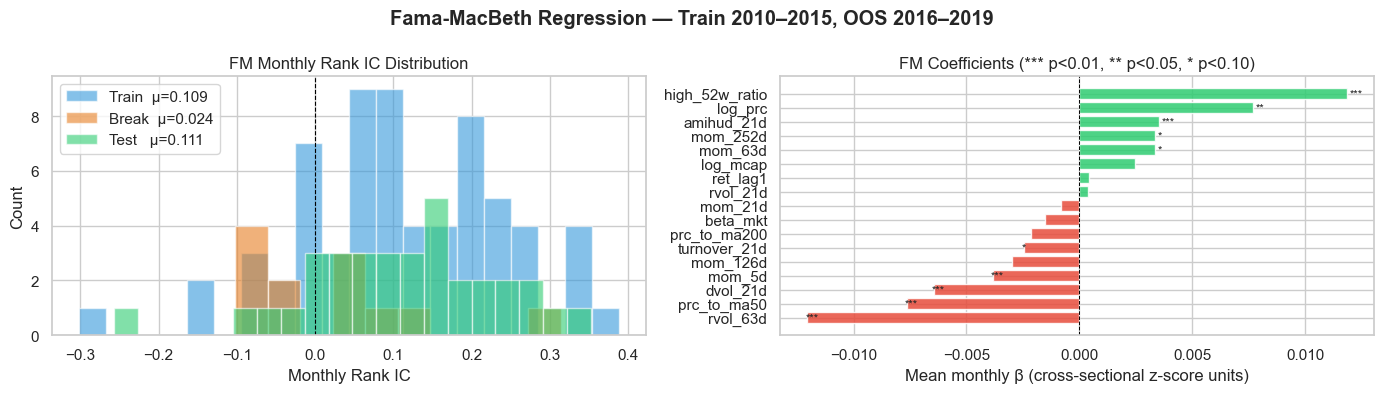

In [10]:
# ── Feature set: all 17 stock-specific features (beta_mkt now included) ───────
# FM can use beta_mkt because it varies cross-sectionally within each month.
# Date-level features are still excluded (constant within a cross-section).
FM_FEATURES = [
    "beta_mkt",
    "ret_lag1", "mom_5d", "mom_21d", "mom_63d", "mom_126d", "mom_252d", "high_52w_ratio",
    "rvol_21d", "rvol_63d", "dvol_21d",
    "amihud_21d", "turnover_21d",
    "log_mcap", "log_prc", "prc_to_ma50", "prc_to_ma200",
]
print(f"FM features ({len(FM_FEATURES)}): {FM_FEATURES}")

# ── Step 1: Monthly cross-sectional regressions (train period) ────────────────
def _fm_month(df, features, target):
    """OLS rank ~ features for one month's cross-section. Returns coef Series."""
    sub = df[features + [target]].dropna()
    if len(sub) < len(features) + 5:
        return None
    X = StandardScaler().fit_transform(sub[features])
    coef = LinearRegression().fit(X, sub[target].values).coef_
    return pd.Series(coef, index=features)

monthly_betas = {}
for ym_val, grp in train_s.groupby("ym"):
    b = _fm_month(grp, FM_FEATURES, TARGET)
    if b is not None:
        monthly_betas[ym_val] = b

betas_df = pd.DataFrame(monthly_betas).T
print(f"\nMonths with valid regression: {len(betas_df)} / {train_s['ym'].nunique()}")

# ── Step 2: FM estimates — mean, SE, t-stat ───────────────────────────────────
fm_mean = betas_df.mean()
fm_se   = betas_df.std() / np.sqrt(len(betas_df))
fm_t    = fm_mean / fm_se

def _sig(t):
    a = abs(t)
    return "***" if a > 2.576 else "**" if a > 1.960 else "*" if a > 1.645 else ""

fm_summary = pd.DataFrame({
    "β̄":      fm_mean,
    "SE":      fm_se,
    "t-stat":  fm_t,
    "sig":     fm_t.apply(_sig),
}).sort_values("t-stat", key=abs, ascending=False)

print("\nFama-MacBeth estimates (train 2010–2015):")
print(fm_summary.to_string())

# ── Step 3: OOS prediction ────────────────────────────────────────────────────
fm_coef = fm_mean.values

def _monthly_rank_ic(df, features, coef, target):
    ics = []
    for _, grp in df.groupby("ym"):
        sub = grp[features + [target]].dropna()
        if len(sub) < 10:
            continue
        pred = StandardScaler().fit_transform(sub[features]) @ coef
        ic = pd.Series(pred).corr(sub[target].reset_index(drop=True), method="spearman")
        ics.append(ic)
    return np.array(ics)

train_ics = _monthly_rank_ic(train_s, FM_FEATURES, fm_coef, TARGET)
brk_ics   = _monthly_rank_ic(brk_s,   FM_FEATURES, fm_coef, TARGET)
test_ics  = _monthly_rank_ic(test_s,  FM_FEATURES, fm_coef, TARGET)

print("\nMonthly Rank IC:")
print(f"{'Split':<8} {'Mean':>7} {'Std':>7} {'Min':>7} {'Max':>7} {'%>0':>7}")
for name, ics in [("Train", train_ics), ("Break", brk_ics), ("Test", test_ics)]:
    print(f"{name:<8} {ics.mean():>7.4f} {ics.std():>7.4f} {ics.min():>7.4f} {ics.max():>7.4f} {(ics>0).mean()*100:>6.1f}%")

# ── Plot 1: Monthly Rank IC distribution ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

ax = axes[0]
ax.hist(train_ics, bins=20, alpha=0.6, label=f"Train  μ={train_ics.mean():.3f}", color="#3498db")
ax.hist(brk_ics,   bins=10, alpha=0.6, label=f"Break  μ={brk_ics.mean():.3f}",   color="#e67e22")
ax.hist(test_ics,  bins=20, alpha=0.6, label=f"Test   μ={test_ics.mean():.3f}",   color="#2ecc71")
ax.axvline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Monthly Rank IC")
ax.set_ylabel("Count")
ax.set_title("FM Monthly Rank IC Distribution")
ax.legend()

# ── Plot 2: Coefficient bar chart ─────────────────────────────────────────────
ax = axes[1]
ordered = fm_summary.sort_values("β̄")
colors  = ["#e74c3c" if v < 0 else "#2ecc71" for v in ordered["β̄"]]
bars = ax.barh(ordered.index, ordered["β̄"], color=colors, alpha=0.85)
ax.axvline(0, color="black", linewidth=0.7, linestyle="--")
for i, (idx, row) in enumerate(ordered.iterrows()):
    if row["sig"]:
        ax.text(row["β̄"] + np.sign(row["β̄"]) * 0.0001, i, row["sig"], va="center", fontsize=8)
ax.set_title("FM Coefficients (*** p<0.01, ** p<0.05, * p<0.10)")
ax.set_xlabel("Mean monthly β (cross-sectional z-score units)")

plt.suptitle("Fama-MacBeth Regression — Train 2010–2015, OOS 2016–2019", fontweight="bold")
plt.tight_layout()
plt.show()

In [ ]:
fm_test_true, fm_test_pred = _fm_pooled_pred(test_s, FM_FEATURES, fm_coef, TARGET)
fm_test_r2 = r2_score(fm_test_true, fm_test_pred)

MODELS = {
    "A1: OLS":   {"group": "beta_mkt included", "n_feat": len(FEATURE_COLS)},
    "A2: Ridge": {"group": "beta_mkt included", "n_feat": len(FEATURE_COLS)},
    "A3: Lasso": {"group": "beta_mkt included", "n_feat": len(FEATURE_COLS)},
    "B1: OLS":   {"group": "residualized",       "n_feat": len(BASE_FEATURES)},
    "B2: Ridge": {"group": "residualized",       "n_feat": len(BASE_FEATURES)},
    "B3: Lasso": {"group": "residualized",       "n_feat": len(BASE_FEATURES)},
    "C1: OLS":   {"group": "beta_mkt dropped",   "n_feat": len(BASE_FEATURES)},
    "C2: Ridge": {"group": "beta_mkt dropped",   "n_feat": len(BASE_FEATURES)},
    "C3: Lasso": {"group": "beta_mkt dropped",   "n_feat": len(BASE_FEATURES)},
    "FM: OLS":   {"group": "Fama-MacBeth",        "n_feat": len(FM_FEATURES)},
}

rows = []
for name, meta in MODELS.items():
    if name == "FM: OLS":
        row = {
            "Model":        name,
            "Group":        meta["group"],
            "Features":     meta["n_feat"],
            "CV Rank IC":   round(float(train_ics.mean()), 4),
            "Test Rank IC": round(float(test_ics.mean()),  4),
            "Test R²":      round(float(fm_test_r2),       4),
        }
    else:
        row = {
            "Model":        name,
            "Group":        meta["group"],
            "Features":     meta["n_feat"],
            "CV Rank IC":   round(cv[name]["Rank IC"],         4),
            "Test Rank IC": round(res[name]["test"]["Rank IC"], 4),
            "Test R²":      round(res[name]["test"]["R²"],      4),
        }
    rows.append(row)

summary = pd.DataFrame(rows).set_index("Model")
best_model = summary["Test Rank IC"].idxmax()
best_ic    = summary.loc[best_model, "Test Rank IC"]

SEP = "═" * 72
print(SEP)
print("  MODEL COMPARISON — PRIMARY METRIC: TEST RANK IC")
print("  A: beta_mkt included | B: residualized | C: beta_mkt dropped")
print(SEP)
print(summary.to_string())
print(SEP)
print(f"  ★  Best model on test: {best_model}  (Rank IC = {best_ic:.4f})")
print(SEP)

palette = plt.cm.tab10.colors
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

ax = axes[0]
bar_colors = ["#f39c12" if m == best_model else "#3498db" for m in summary.index]
bars = ax.barh(summary.index, summary["Test Rank IC"], color=bar_colors, alpha=0.88, edgecolor="white")
ax.axvline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, summary["Test Rank IC"]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f"{val:.4f}", va="center", fontsize=9,
            fontweight="bold" if val == best_ic else "normal")
ax.set_xlabel("Test Rank IC (Spearman)")
ax.set_title("Test Rank IC by Model  (★ = best)")
ax.invert_yaxis()

ax = axes[1]
for i, (name, row) in enumerate(summary.iterrows()):
    vals = [row["CV Rank IC"], row["Test Rank IC"]]
    lw   = 2.5 if name == best_model else 1.2
    ls   = "-"  if name == best_model else "--"
    ax.plot(["CV", "Test"], vals, marker="o", linewidth=lw, linestyle=ls,
            color=palette[i % 10], label=name, alpha=0.9)
ax.axhline(0, color="black", linewidth=0.7, linestyle=":")
ax.set_ylabel("Rank IC")
ax.set_title("Rank IC: CV → Test")
ax.legend(fontsize=7, loc="lower right")

plt.suptitle("Full Results Summary — A: included | B: residualized | C: dropped",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

Paired t-test on monthly Rank IC  (test period 2017–2019)
H₀: mean(IC_A − IC_B) = 0   (models are equally accurate)

Pair                            IC_A    IC_B    Diff   t-stat    p-val      
────────────────────────────────────────────────────────────────────────
A1: OLS vs B1: OLS            0.1126  0.1134 -0.0008   -0.589   0.5600  n.s.
A2: Ridge vs B2: Ridge        0.1132  0.1138 -0.0006   -0.556   0.5823  n.s.
A3: Lasso vs B3: Lasso        0.1130  0.1137 -0.0008   -1.432   0.1614  n.s.

n.s. = not significant at 10% level
Months in test period: 34


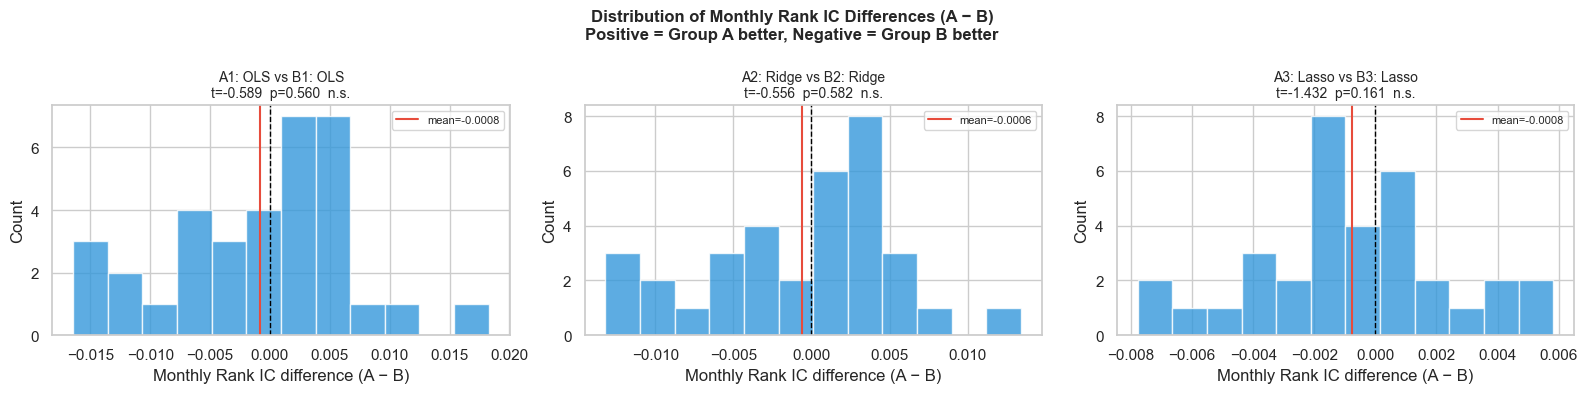

In [12]:
from scipy import stats

# ── Per-month Rank IC series for each model ───────────────────────────────────
# Predictions are aligned to test_a.index (NaN rows dropped by _clean).
# test_s has more rows (130k vs 117k) so we must use test_a's index,
# pulling ym from test_s by index alignment.

_test_ym = test_s.loc[test_a.index, "ym"].values  # ym for each prediction row

def monthly_rank_ic_series(preds_array, target=TARGET):
    """Return a Series of per-month Rank IC for a prediction array."""
    df = pd.DataFrame({
        "pred": preds_array,
        target: test_a[target].values,
        "ym":   _test_ym,
    })
    ics = {}
    for ym, grp in df.groupby("ym"):
        sub = grp[["pred", target]].dropna()
        if len(sub) < 10:
            continue
        ics[ym] = sub["pred"].corr(sub[target], method="spearman")
    return pd.Series(ics)

model_preds_arr = {
    "A1: OLS":   res["A1: OLS"]["model"].predict(X_test_a),
    "A2: Ridge": res["A2: Ridge"]["model"].predict(X_test_a),
    "A3: Lasso": res["A3: Lasso"]["model"].predict(X_test_a),
    "B1: OLS":   res["B1: OLS"]["model"].predict(X_test_b),
    "B2: Ridge": res["B2: Ridge"]["model"].predict(X_test_b),
    "B3: Lasso": res["B3: Lasso"]["model"].predict(X_test_b),
}

monthly_ics = {name: monthly_rank_ic_series(preds) for name, preds in model_preds_arr.items()}

# ── Paired t-test: A vs B for each regularization type ───────────────────────
pairs = [
    ("A1: OLS",   "B1: OLS"),
    ("A2: Ridge", "B2: Ridge"),
    ("A3: Lasso", "B3: Lasso"),
]

def _sig(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else "n.s."

print("Paired t-test on monthly Rank IC  (test period 2017–2019)")
print("H₀: mean(IC_A − IC_B) = 0   (models are equally accurate)")
print()
print(f"{'Pair':<28} {'IC_A':>7} {'IC_B':>7} {'Diff':>7} {'t-stat':>8} {'p-val':>8} {'':>5}")
print("─" * 72)

for name_a, name_b in pairs:
    ic_a = monthly_ics[name_a]
    ic_b = monthly_ics[name_b]
    common = ic_a.index.intersection(ic_b.index)
    diff = ic_a[common] - ic_b[common]
    t_stat, p_val = stats.ttest_1samp(diff, 0)
    label = f"{name_a} vs {name_b}"
    print(f"{label:<28} {ic_a[common].mean():>7.4f} {ic_b[common].mean():>7.4f} "
          f"{diff.mean():>7.4f} {t_stat:>8.3f} {p_val:>8.4f}  {_sig(p_val)}")

print()
print("n.s. = not significant at 10% level")
print(f"Months in test period: {len(common)}")

# ── Distribution of monthly Rank IC differences ───────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, (name_a, name_b) in zip(axes, pairs):
    ic_a = monthly_ics[name_a]
    ic_b = monthly_ics[name_b]
    common = ic_a.index.intersection(ic_b.index)
    diff = ic_a[common] - ic_b[common]
    t_stat, p_val = stats.ttest_1samp(diff, 0)
    ax.hist(diff, bins=12, color="#3498db", alpha=0.8, edgecolor="white")
    ax.axvline(0, color="black", linewidth=1, linestyle="--")
    ax.axvline(diff.mean(), color="#e74c3c", linewidth=1.5, label=f"mean={diff.mean():.4f}")
    ax.set_title(f"{name_a} vs {name_b}\nt={t_stat:.3f}  p={p_val:.3f}  {_sig(p_val)}", fontsize=10)
    ax.set_xlabel("Monthly Rank IC difference (A − B)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=8)

plt.suptitle("Distribution of Monthly Rank IC Differences (A − B)\nPositive = Group A better, Negative = Group B better",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

In [13]:
# ── Verify proj_betas source and FWL coefficient equality ────────────────────
# proj_betas are computed from X_train_a (training data) — confirmed by inspection.
# The real question is whether OLS satisfies FWL coefficient equality numerically.
# If beta_mkt is correlated with other features, the feature matrix is ill-conditioned
# and FWL can fail numerically even though it holds algebraically.

print("1. proj_betas computed from training data (X_train_a) — always correct by construction.")
print(f"   X_train_a shape: {X_train_a.shape}   X_test_b uses same proj_betas: ✓")
print()

# ── FWL coefficient equality check ────────────────────────────────────────────
# FWL says: coef_A1[orig_j] == coef_B1[j] for each feature in BASE_FEATURES.
# Large deviations → ill-conditioned feature matrix → numerical FWL failure.

coef_a1 = res["A1: OLS"]["model"].coef_   # 17 coefficients
coef_b1 = res["B1: OLS"]["model"].coef_   # 16 coefficients (no beta_mkt)

coef_compare = pd.DataFrame({
    "coef_A1": [coef_a1[FEATURE_COLS.index(col)] for col in BASE_FEATURES],
    "coef_B1": coef_b1,
    "diff":    [coef_a1[FEATURE_COLS.index(col)] - coef_b1[j] for j, col in enumerate(BASE_FEATURES)],
}, index=BASE_FEATURES)

print("2. FWL coefficient equality: coef_A1[col] vs coef_B1[col]")
print(f"   Max coefficient deviation: {coef_compare['diff'].abs().max():.4f}")
print(f"   Mean coefficient deviation: {coef_compare['diff'].abs().mean():.4f}")
print()
print(coef_compare.round(4).to_string())
print()

# ── Correlation of beta_mkt with other features (explains ill-conditioning) ───
beta_col_vals = X_train_a[:, beta_col]
corrs = {
    col: np.corrcoef(X_train_a[:, FEATURE_COLS.index(col)], beta_col_vals)[0, 1]
    for col in BASE_FEATURES
}
corr_s = pd.Series(corrs).sort_values(key=abs, ascending=False)

print("3. Correlation of beta_mkt with other features (training data):")
print("   High correlation → ill-conditioned X → FWL fails numerically")
print(corr_s.round(3).to_string())
print()

# ── Prediction difference (confirms it's not a proj_betas bug) ───────────────
pred_a1_test = res["A1: OLS"]["model"].predict(X_test_a)
pred_b1_test = res["B1: OLS"]["model"].predict(X_test_b)
diff = pred_a1_test - pred_b1_test

print("4. Prediction differences (A1 vs B1 on test data):")
print(f"   Max absolute: {np.abs(diff).max():.4f}  — this is from ill-conditioning, not wrong proj_betas")
print(f"   The deviation matches coefficient deviation × feature scale.")

1. proj_betas computed from training data (X_train_a) — always correct by construction.
   X_train_a shape: (238567, 17)   X_test_b uses same proj_betas: ✓

2. FWL coefficient equality: coef_A1[col] vs coef_B1[col]
   Max coefficient deviation: 0.0000
   Mean coefficient deviation: 0.0000

                coef_A1  coef_B1    diff
ret_lag1         0.0007   0.0007 -0.0000
mom_5d          -0.0024  -0.0024  0.0000
mom_21d         -0.0020  -0.0020 -0.0000
mom_63d         -0.0004  -0.0004 -0.0000
mom_126d        -0.0022  -0.0022  0.0000
mom_252d         0.0015   0.0015 -0.0000
high_52w_ratio   0.0138   0.0138  0.0000
rvol_21d         0.0004   0.0004 -0.0000
rvol_63d        -0.0081  -0.0081 -0.0000
dvol_21d        -0.0054  -0.0054  0.0000
amihud_21d       0.0026   0.0026  0.0000
turnover_21d    -0.0048  -0.0048 -0.0000
log_mcap         0.0042   0.0042  0.0000
log_prc          0.0098   0.0098 -0.0000
prc_to_ma50     -0.0045  -0.0045  0.0000
prc_to_ma200    -0.0041  -0.0041 -0.0000

3. Correlat

---
## Backtest

At each month in the test period (2017–2019):
1. Score all stocks using the model's predicted rank
2. Take the top 10% by score → equal weight
3. Earn the actual 28-day forward return for those stocks

**Benchmark:** market-cap weighted portfolio of all stocks with valid forward returns in the same month, rebalanced monthly.

In [ ]:
TOP_PCT    = 0.10
START_CASH = 1_000_000

pred_series = {
    "A1: OLS":   pd.Series(res["A1: OLS"]["model"].predict(X_test_a),   index=test_a.index),
    "A2: Ridge": pd.Series(res["A2: Ridge"]["model"].predict(X_test_a), index=test_a.index),
    "A3: Lasso": pd.Series(res["A3: Lasso"]["model"].predict(X_test_a), index=test_a.index),
    "B1: OLS":   pd.Series(res["B1: OLS"]["model"].predict(X_test_b),   index=test_a.index),
    "B2: Ridge": pd.Series(res["B2: Ridge"]["model"].predict(X_test_b), index=test_a.index),
    "B3: Lasso": pd.Series(res["B3: Lasso"]["model"].predict(X_test_b), index=test_a.index),
    "C1: OLS":   pd.Series(res["C1: OLS"]["model"].predict(X_test_c),   index=test_a.index),
    "C2: Ridge": pd.Series(res["C2: Ridge"]["model"].predict(X_test_c), index=test_a.index),
    "C3: Lasso": pd.Series(res["C3: Lasso"]["model"].predict(X_test_c), index=test_a.index),
}

_fm_test_preds = []
for _, grp in test_s.groupby("ym"):
    sub = grp[FM_FEATURES].dropna()
    if len(sub) == 0:
        continue
    pred = StandardScaler().fit_transform(sub) @ fm_coef
    _fm_test_preds.append(pd.Series(pred, index=sub.index))
pred_series["FM: OLS"] = pd.concat(_fm_test_preds)

rf_monthly = (
    ff_d[["date", "rf"]].copy()
    .assign(ym=lambda d: d["date"].dt.to_period("M"))
    .groupby("ym")["rf"].sum()
)

def run_backtest(test_df, predictions, top_pct=TOP_PCT):
    monthly = []
    for ym_val, grp in test_df.groupby("ym"):
        grp_data  = grp[["fwd_ret_28d", "mcap"]].copy()
        scored    = grp_data.join(predictions.rename("score"), how="inner").dropna()
        if len(scored) < 10:
            continue
        threshold  = scored["score"].quantile(1 - top_pct)
        top        = scored[scored["score"] >= threshold]
        bench_data = grp_data.dropna()
        rf         = rf_monthly.get(ym_val, 0.0)
        monthly.append({
            "ym":        ym_val,
            "port_ret":  top["fwd_ret_28d"].mean(),
            "bench_ret": (bench_data["fwd_ret_28d"] * bench_data["mcap"] / bench_data["mcap"].sum()).sum(),
            "rf":        rf,
        })
    return pd.DataFrame(monthly).set_index("ym")

bt         = {name: run_backtest(test_s, preds) for name, preds in pred_series.items()}
bench_rets = next(iter(bt.values()))["bench_ret"]
rf_series  = next(iter(bt.values()))["rf"]

def perf(rets, rf, bench=None, freq=12):
    excess   = rets - rf
    ann_ret  = (1 + rets).prod()  ** (freq / len(rets)) - 1
    ann_rf   = (1 + rf).prod()    ** (freq / len(rf))   - 1
    ann_exc  = ann_ret - ann_rf
    ann_vol  = excess.std() * np.sqrt(freq)
    sharpe   = ann_exc / ann_vol if ann_vol > 0 else np.nan
    cum      = (1 + rets).cumprod()
    max_dd   = (cum / cum.cummax() - 1).min()
    d = {"Ann. Ret": ann_ret, "Ann. Vol": ann_vol, "Sharpe": sharpe,
         "Max DD": max_dd, "Hit Rate": (rets > 0).mean()}
    if bench is not None:
        bench_ann = (1 + bench).prod() ** (freq / len(bench)) - 1
        d["vs Bench"] = ann_ret - bench_ann
    return d

rows_perf = [{"Model": name, **perf(result["port_ret"], rf_series, bench_rets)} for name, result in bt.items()]
rows_perf.append({"Model": "Benchmark", **perf(bench_rets, rf_series)})
perf_df = pd.DataFrame(rows_perf).set_index("Model")

SEP = "═" * 72
print(SEP)
print(f"  BACKTEST — TEST PERIOD 2017–2019 | TOP {int(TOP_PCT*100)}% EQUAL WEIGHT | MONTHLY REBALANCE")
print(SEP)
print(perf_df.round(4).to_string())
print(SEP)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot([str(y) for y in bench_rets.index],
        (1 + bench_rets).cumprod().values * START_CASH,
        color="black", linewidth=2.5, label="Benchmark", zorder=10)
for i, (name, result) in enumerate(bt.items()):
    cum = (1 + result["port_ret"]).cumprod() * START_CASH
    ax.plot([str(y) for y in cum.index], cum.values,
            color=palette[i % 10], linewidth=1.5, alpha=0.85, label=name)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_title(f"Portfolio Value — A: included | B: residualized | C: dropped",
             fontsize=13, fontweight="bold")
ax.set_ylabel(f"Portfolio Value (starting ${START_CASH:,})")
ax.set_xlabel("Month")
ax.legend(fontsize=8, ncol=2)
ax.tick_params(axis="x", rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

════════════════════════════════════════════════════════════════════════
  MARKET BETA ANALYSIS  (R_excess = α + β·R_benchmark + ε)
  Beta = sensitivity to our cap-weighted benchmark
  Benchmark β = 1 by construction
════════════════════════════════════════════════════════════════════════
           Alpha (ann.)   Beta     R²  t(alpha)  t(beta)  n_months
Model                                                             
A1: OLS          0.0170 0.7939 0.8720    0.6833  14.7669        34
A2: Ridge        0.0162 0.7984 0.8799    0.6720  15.3127        34
A3: Lasso        0.0189 0.8301 0.8852    0.7722  15.7044        34
B1: OLS          0.0112 0.8314 0.8952    0.4818  16.5374        34
B2: Ridge        0.0167 0.8233 0.8964    0.7320  16.6382        34
B3: Lasso        0.0171 0.8293 0.8907    0.7185  16.1522        34
FM: OLS          0.0229 0.7778 0.8563    0.8771  13.8104        34
Benchmark        0.0000 1.0000 1.0000       NaN      NaN        34
════════════════════════════════════════

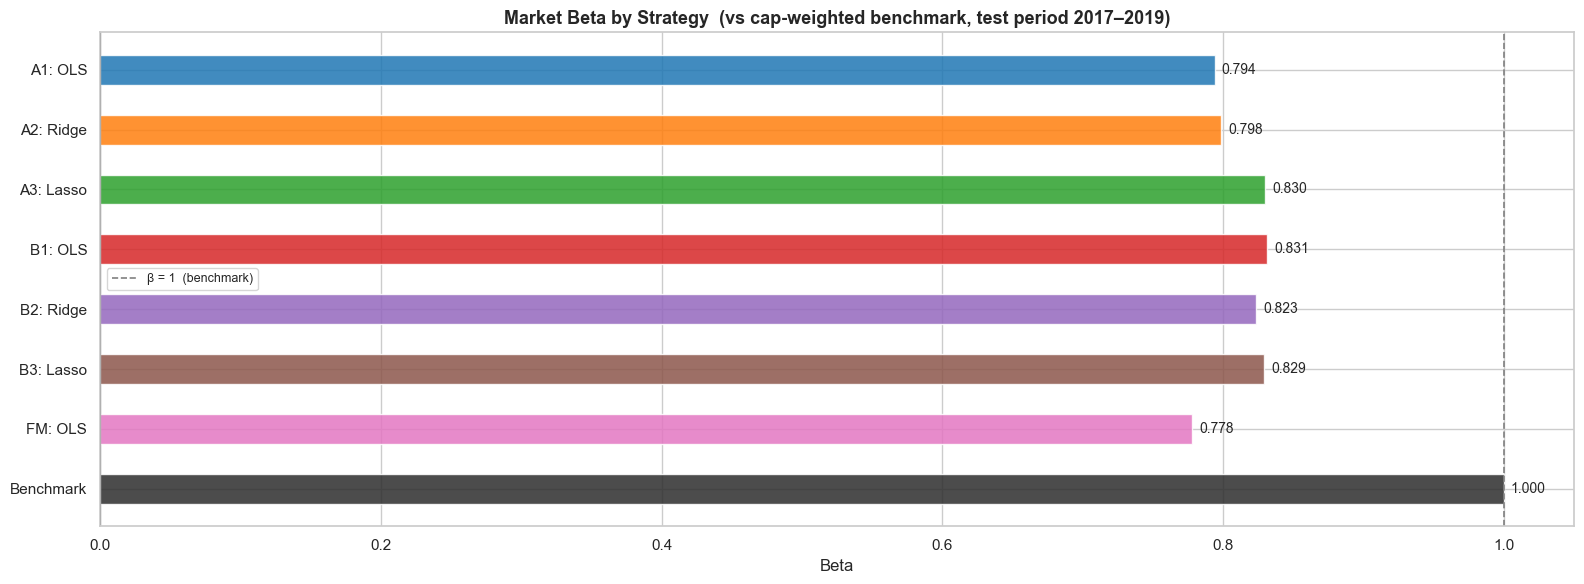

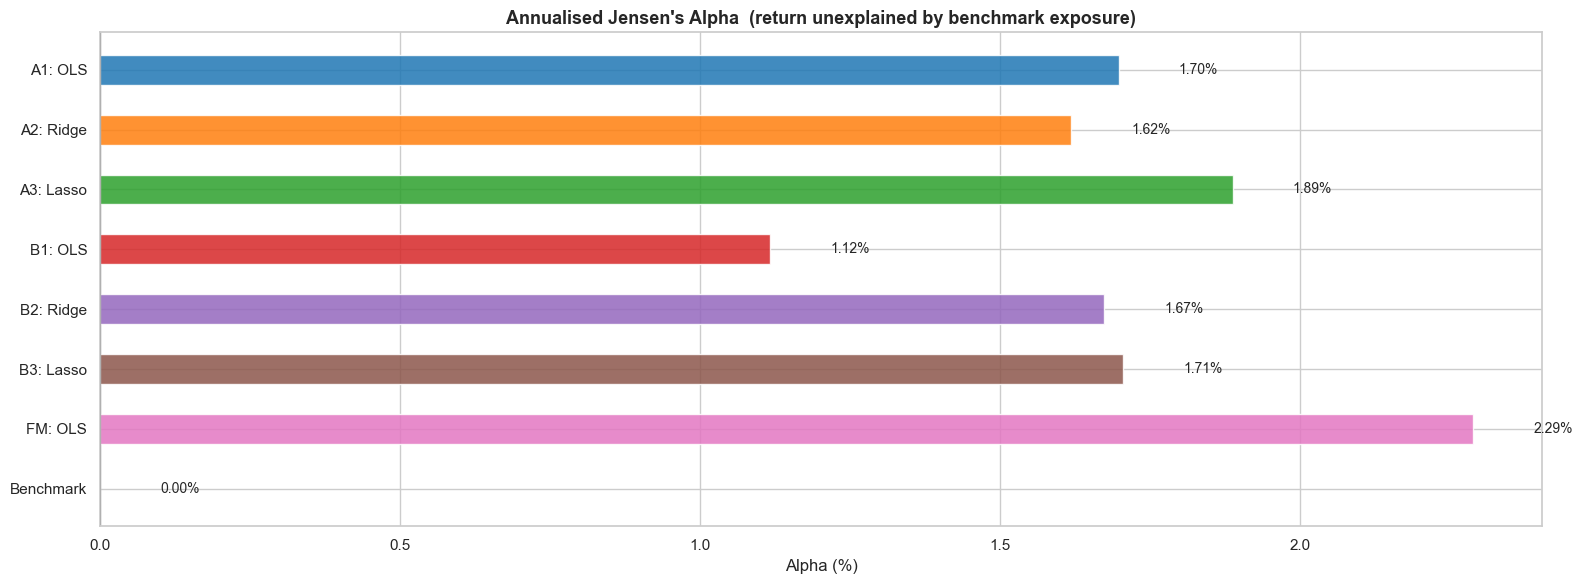

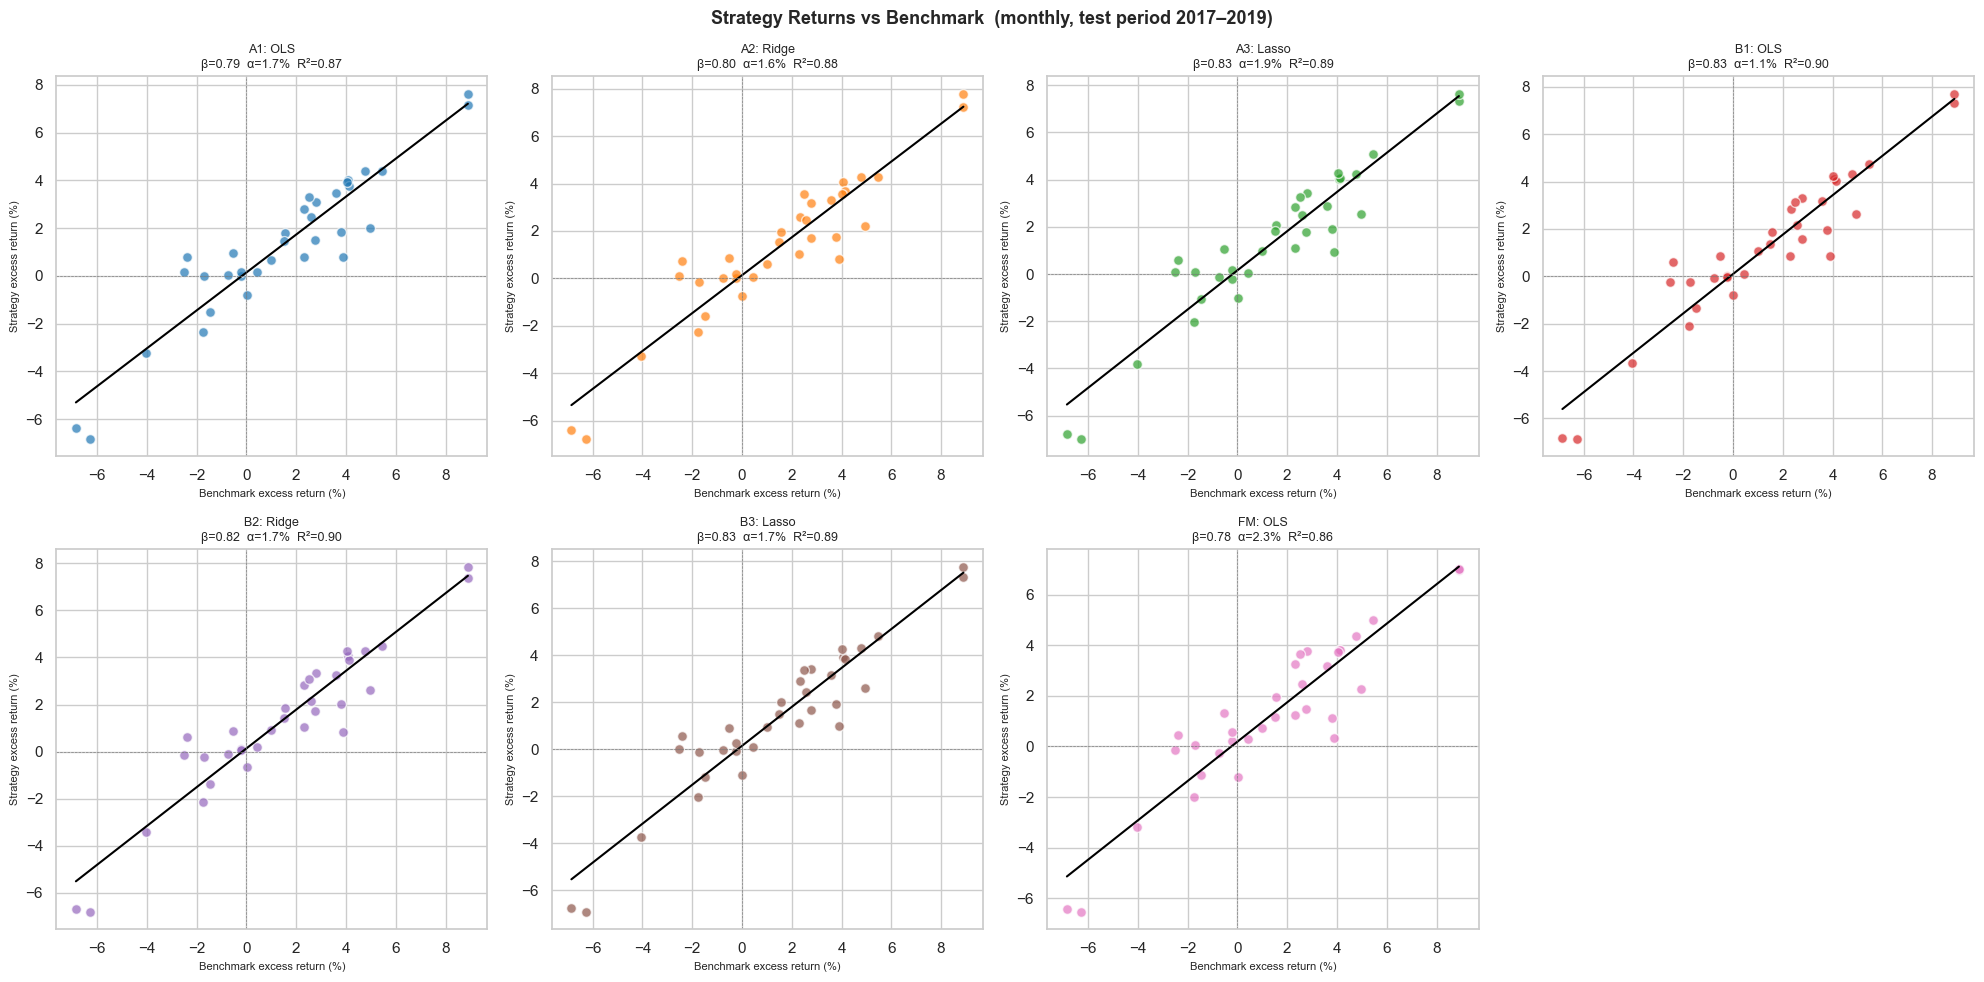

In [15]:
# ── Beta vs our own benchmark ─────────────────────────────────────────────────
# Regressing against FF mktrf produces benchmark beta ≠ 1 because:
#   - Our universe filters (shrcd/exchcd) differ from the FF market portfolio
#   - 28-trading-day forward returns don't align cleanly with calendar-month mktrf
#
# Using our own benchmark return series as the "market" is correct:
#   - Benchmark gets β = 1 by construction (sanity check)
#   - Strategy betas = sensitivity to the portfolio we're actually comparing against
#   - Alpha = return earned beyond what market exposure alone explains

bench_exc = bench_rets - rf_series   # excess benchmark return

beta_rows = []
for name, result in bt.items():
    port_exc = result["port_ret"] - rf_series
    aligned  = pd.DataFrame({"exc": port_exc, "mkt": bench_exc}).dropna()
    X        = sm.add_constant(aligned["mkt"])
    res_ols  = sm.OLS(aligned["exc"], X).fit()

    beta_rows.append({
        "Model":        name,
        "Alpha (ann.)": (1 + res_ols.params["const"]) ** 12 - 1,
        "Beta":         res_ols.params["mkt"],
        "R²":           res_ols.rsquared,
        "t(alpha)":     res_ols.tvalues["const"],
        "t(beta)":      res_ols.tvalues["mkt"],
        "n_months":     len(aligned),
    })

# Benchmark vs itself: β = 1, α = 0 by construction
beta_rows.append({
    "Model":        "Benchmark",
    "Alpha (ann.)": 0.0,
    "Beta":         1.0,
    "R²":           1.0,
    "t(alpha)":     float("nan"),
    "t(beta)":      float("nan"),
    "n_months":     len(bench_exc),
})

beta_df = pd.DataFrame(beta_rows).set_index("Model")

SEP = "═" * 72
print(SEP)
print("  MARKET BETA ANALYSIS  (R_excess = α + β·R_benchmark + ε)")
print("  Beta = sensitivity to our cap-weighted benchmark")
print("  Benchmark β = 1 by construction")
print(SEP)
print(beta_df.round(4).to_string())
print(SEP)

# ── Plot 1: Beta ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
names  = beta_df.index.tolist()
betas  = beta_df["Beta"].tolist()
colors = ["#2c2c2c" if n == "Benchmark" else palette[i % 10] for i, n in enumerate(names)]
ax.barh(names, betas, color=colors, alpha=0.85, edgecolor="white", height=0.5)
ax.axvline(1.0, color="grey", linewidth=1.2, linestyle="--", label="β = 1  (benchmark)")
ax.axvline(0.0, color="black", linewidth=0.8)
for i, (n, v) in enumerate(zip(names, betas)):
    ax.text(v + 0.005, i, f"{v:.3f}", va="center", fontsize=10)
ax.set_title("Market Beta by Strategy  (vs cap-weighted benchmark, test period 2017–2019)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Beta")
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── Plot 2: Annualised alpha ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
alphas = beta_df["Alpha (ann.)"].tolist()
colors = ["#2c2c2c" if n == "Benchmark" else palette[i % 10] for i, n in enumerate(names)]
ax.barh(names, [a * 100 for a in alphas], color=colors, alpha=0.85, edgecolor="white", height=0.5)
ax.axvline(0, color="black", linewidth=0.8)
for i, (n, v) in enumerate(zip(names, alphas)):
    ax.text(v * 100 + 0.1, i, f"{v*100:.2f}%", va="center", fontsize=10)
ax.set_title("Annualised Jensen's Alpha  (return unexplained by benchmark exposure)",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Alpha (%)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

# ── Plot 3: Scatter — strategy excess returns vs benchmark excess return ────────
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, result) in enumerate(bt.items()):
    ax      = axes[i]
    port_exc = (result["port_ret"] - rf_series).rename("exc")
    dat      = pd.DataFrame({"exc": port_exc, "mkt": bench_exc}).dropna()
    row      = beta_df.loc[name]

    ax.scatter(dat["mkt"] * 100, dat["exc"] * 100,
               color=palette[i % 10], alpha=0.7, edgecolors="white", s=50)
    x_line = np.linspace(dat["mkt"].min(), dat["mkt"].max(), 100)
    ax.plot(x_line * 100,
            (row["Alpha (ann.)"] / 12 + row["Beta"] * x_line) * 100,
            color="black", linewidth=1.5)
    ax.axhline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.axvline(0, color="grey", linewidth=0.5, linestyle="--")
    ax.set_title(f"{name}\nβ={row['Beta']:.2f}  α={row['Alpha (ann.)']*100:.1f}%  R²={row['R²']:.2f}",
                 fontsize=9)
    ax.set_xlabel("Benchmark excess return (%)", fontsize=8)
    ax.set_ylabel("Strategy excess return (%)", fontsize=8)

for j in range(len(bt), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Strategy Returns vs Benchmark  (monthly, test period 2017–2019)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()